In [1]:
import math, json, time, random
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#08090e", "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e", "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4", "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62", "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,       "lines.linewidth":  1.8,
    "font.family":      "monospace","font.size":        10,
})
ORANGE = "#e8a020"; BLUE = "#6ab0f5"; GREEN  = "#4ade80"
RED    = "#f87171"; CYAN  = "#67e8f9"; PURPLE = "#a78bfa"
MUTED  = "#4a4d62"; GOLD  = "#fbbf24"

torch.manual_seed(42)
random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}  |  device: {device}")


torch 2.11.0+cpu  |  device: cpu


In [2]:
# ── EML building blocks (self-contained) ────────────────────────────────────

class ScalarLeaf(nn.Module):
    # Trainable scalar constant
    def __init__(self, init=1.0):
        super().__init__()
        self.val = nn.Parameter(torch.tensor(float(init)))
    def forward(self, _x=None): return self.val.expand(1)
    def formula(self, names=None): return f"{self.val.item():.4g}"

class FnLeaf(nn.Module):
    # Affine leaf: w*x + b
    def __init__(self, in_features=1):
        super().__init__()
        self.lin = nn.Linear(in_features, 1)
    def forward(self, x): return self.lin(x).squeeze(-1)
    def formula(self, names=None):
        w = self.lin.weight.item()
        b = self.lin.bias.item()
        return f"({w:.4g}*x+{b:.4g})"

class FixedLeaf(nn.Module):
    # Non-trainable constant leaf (frozen at 1.0)
    def __init__(self):
        super().__init__()
        self.register_buffer('val', torch.ones(1))
    def forward(self, _x=None): return self.val
    def formula(self, names=None): return "1"

class EMLNode(nn.Module):
    def __init__(self, left, right):
        super().__init__()
        self.left, self.right = left, right
    def forward(self, x=None):
        lv = self.left(x)
        rv = F.softplus(self.right(x))
        return torch.exp(lv) - torch.log(rv)
    def formula(self, names=None):
        return f"eml({self.left.formula(names)},{self.right.formula(names)})"

def build(shape, leaf_fn):
    if shape == 'L': return leaf_fn()
    _, l, r = shape
    return EMLNode(build(l, leaf_fn), build(r, leaf_fn))

# helpers
def _depth(s):
    if s == 'L': return 0
    return 1 + max(_depth(s[1]), _depth(s[2]))

def _leaves(s):
    if s == 'L': return 1
    return _leaves(s[1]) + _leaves(s[2])

def _desc(s):
    if s == 'L': return '1'
    return f"eml({_desc(s[1])},{_desc(s[2])})"

def _balance(s):
    # Imbalance = max |left_depth - right_depth| across all nodes
    if s == 'L': return 0
    ld, rd = _depth(s[1]), _depth(s[2])
    return max(abs(ld - rd), _balance(s[1]), _balance(s[2]))

print("Building blocks ready.")
print(f"  ScalarLeaf, FnLeaf, FixedLeaf, EMLNode, build()")
print(f"  Helpers: _depth, _leaves, _desc, _balance")


Building blocks ready.
  ScalarLeaf, FnLeaf, FixedLeaf, EMLNode, build()
  Helpers: _depth, _leaves, _desc, _balance


In [3]:
# ── Part A: topology pool ────────────────────────────────────────────────────
# Full enumeration depth 1-4, then balanced random sampling for depth 5

_tc_memo: dict = {}
def trees_n(n: int) -> list:
    if n in _tc_memo: return _tc_memo[n]
    if n == 0:
        _tc_memo[0] = ['L']
        return _tc_memo[0]
    result = []
    for i in range(n):
        for l in trees_n(i):
            for r in trees_n(n - 1 - i):
                result.append(('N', l, r))
    _tc_memo[n] = result
    return result

# Known phantom descriptors to skip
PHANTOM_DESCS = {
    'eml(1,1)',
    'eml(eml(1,1),1)',
    'eml(eml(1,eml(1,1)),1)',
}

# ── depth 1-4 full enumeration ────────────────────────────────────────────────
depth14 = [s for n in range(1, 5) for s in trees_n(n)
           if _desc(s) not in PHANTOM_DESCS]

# ── depth-5 balanced pool ─────────────────────────────────────────────────────
# All 42 depth-5 trees; keep only those with recursive balance score ≤ 1
# (|left_depth - right_depth| ≤ 1 at EVERY node, not just root)
all_d5 = trees_n(5)  # 42 trees

balanced_d5 = [s for s in all_d5 if _balance(s) <= 1
               and _desc(s) not in PHANTOM_DESCS]

ALL_SHAPES = depth14 + balanced_d5
# deduplicate by descriptor
seen = set(); unique_shapes = []
for s in ALL_SHAPES:
    d = _desc(s)
    if d not in seen:
        seen.add(d)
        unique_shapes.append(s)

print(f"Depth 1-4 (after phantom removal)       : {len(depth14)}")
print(f"Depth-5 fully balanced (balance ≤ 1)   : {len(balanced_d5)}")
print(f"Total unique candidate topologies       : {len(unique_shapes)}")
print()

# Print balance distribution
from collections import Counter
bal_counts = Counter(_balance(s) for s in unique_shapes)
print("Balance score distribution (lower = more balanced):")
for k in sorted(bal_counts):
    bar = '█' * bal_counts[k]
    print(f"  score {k}: {bal_counts[k]:3d}  {bar}")
print()

# Print topology table
print(f"{'#':<4} {'D':<4} {'L':<4} {'Bal':<5} {'Desc'}")
print('─' * 72)
for i, s in enumerate(unique_shapes):
    print(f"{i+1:<4} {_depth(s):<4} {_leaves(s):<4} {_balance(s):<5} {_desc(s)[:55]}")


Depth 1-4 (after phantom removal)       : 19
Depth-5 fully balanced (balance ≤ 1)   : 6
Total unique candidate topologies       : 25

Balance score distribution (lower = more balanced):
  score 0:   1  █
  score 1:  11  ███████████
  score 2:   5  █████
  score 3:   8  ████████

#    D    L    Bal   Desc
────────────────────────────────────────────────────────────────────────
1    2    3    1     eml(1,eml(1,1))
2    3    4    2     eml(1,eml(1,eml(1,1)))
3    3    4    2     eml(1,eml(eml(1,1),1))
4    2    4    0     eml(eml(1,1),eml(1,1))
5    3    4    2     eml(eml(eml(1,1),1),1)
6    4    5    3     eml(1,eml(1,eml(1,eml(1,1))))
7    4    5    3     eml(1,eml(1,eml(eml(1,1),1)))
8    3    5    2     eml(1,eml(eml(1,1),eml(1,1)))
9    4    5    3     eml(1,eml(eml(1,eml(1,1)),1))
10   4    5    3     eml(1,eml(eml(eml(1,1),1),1))
11   3    5    1     eml(eml(1,1),eml(1,eml(1,1)))
12   3    5    1     eml(eml(1,1),eml(eml(1,1),1))
13   3    5    1     eml(eml(1,eml(1,1)),eml(1,1))


In [4]:
# ── Main search (affine pass) + focused mixed refinement ─────────────────────

def search_affine(shapes, x_in, y_target, target_name,
                  lam=5e-5, num_restarts=5, steps=800, lr=0.005):
    # Affine-only search: all leaves are FnLeaf.
    # Fast enough for the full topology pool.
    records = []
    n_shapes = len(shapes)

    for idx, shape in enumerate(shapes):
        best_loss, best_model = float('inf'), None
        r_losses = []

        for r in range(num_restarts):
            torch.manual_seed(r * 997 + 3)
            model = build(shape, lambda: FnLeaf(in_features=1))
            opt   = torch.optim.Adam(model.parameters(), lr=lr)
            last  = float('inf')
            for _ in range(steps):
                opt.zero_grad()
                try:
                    pred     = model(x_in)
                    raw_loss = F.mse_loss(pred, y_target)
                    if not torch.isfinite(raw_loss): break
                    l1_pen = lam * sum(p.abs().sum()
                                       for nm, p in model.named_parameters()
                                       if 'weight' in nm)
                    (raw_loss + l1_pen).backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    last = raw_loss.item()
                except Exception: break
            r_losses.append(last)
            if last < best_loss:
                best_loss, best_model = last, model

        spread = max(r_losses) - min(r_losses) if r_losses else 0
        is_ph  = (min(r_losses) > 1e-3) and (spread < 1e-3)

        rec = dict(
            shape   = shape,
            depth   = _depth(shape),
            leaves  = _leaves(shape),
            balance = _balance(shape),
            desc    = _desc(shape),
            loss    = best_loss,
            phantom = is_ph,
            formula = best_model.formula(['x']) if best_model else 'N/A',
            _model  = best_model,
        )
        records.append(rec)

        if (idx + 1) % 5 == 0 or (idx + 1) == n_shapes:
            best_so_far = min(r['loss'] for r in records)
            print(f"  [{idx+1:3d}/{n_shapes}] best so far: {best_so_far:.4e}")

    records.sort(key=lambda r: r['loss'])
    return records


def refine_mixed(top_records, x_in, y_target,
                 lam=5e-5, num_restarts=2, steps=800, lr=0.005):
    # Mixed-leaf refinement on top N shapes:
    # leftmost leaf is FnLeaf, rest are ScalarLeaf.
    # Returns list of (desc, loss_mixed) pairs.
    results = []
    for rec in top_records:
        shape = rec['shape']
        best_loss, best_model = float('inf'), None
        _leaf_counter = [0]
        def mixed_leaf():
            _leaf_counter[0] += 1
            if _leaf_counter[0] == 1:
                return FnLeaf(in_features=1)
            return ScalarLeaf(init=1.0)

        for r in range(num_restarts):
            torch.manual_seed(r * 997 + 7)
            _leaf_counter[0] = 0
            model = build(shape, mixed_leaf)
            opt   = torch.optim.Adam(model.parameters(), lr=lr)
            last  = float('inf')
            for _ in range(steps):
                opt.zero_grad()
                try:
                    pred     = model(x_in)
                    if pred.shape != y_target.shape:
                        pred = pred.expand_as(y_target)
                    raw_loss = F.mse_loss(pred, y_target)
                    if not torch.isfinite(raw_loss): break
                    l1_pen = lam * sum(p.abs().sum()
                                       for nm, p in model.named_parameters()
                                       if 'weight' in nm)
                    (raw_loss + l1_pen).backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    last = raw_loss.item()
                except Exception: break
            if last < best_loss:
                best_loss, best_model = last, model

        results.append(dict(
            desc       = rec['desc'],
            loss_aff   = rec['loss'],
            loss_mixed = best_loss,
            best       = min(rec['loss'], best_loss),
            pass_won   = 'affine' if rec['loss'] <= best_loss else 'mixed',
            formula    = best_model.formula(['x']) if best_model and best_loss < rec['loss'] else rec['formula'],
            _model     = best_model if best_loss < rec['loss'] else rec['_model'],
        ))

    results.sort(key=lambda r: r['best'])
    return results

print("search_affine() and refine_mixed() ready.")
print(f"  Main: 5 restarts x 800 steps (affine) over full pool")
print(f"  Refine: 2 restarts x 800 steps (mixed) on top-3 per target")


search_affine() and refine_mixed() ready.
  Main: 5 restarts x 800 steps (affine) over full pool
  Refine: 2 restarts x 800 steps (mixed) on top-3 per target


In [5]:
# ── Part B: run sin(x) and cos(x) searches ───────────────────────────────────

x_grid     = torch.linspace(0, 2*math.pi, 100)
sin_target = torch.sin(x_grid)
cos_target = torch.cos(x_grid)
x_in       = x_grid.unsqueeze(1)   # (100, 1)

PREV_BEST_SIN = 7.76e-4   # from experiment_04
PREV_BEST_COS = 1.62e-3   # from experiment_04

# ── Phase 1: affine search over full pool ─────────────────────────────────────
print(f"Phase 1 — affine search on {len(unique_shapes)} topologies (sin) ...")
t0 = time.time()
sin_results = search_affine(unique_shapes, x_in, sin_target, 'sin(x)')
print(f"  sin done in {time.time()-t0:.1f}s")

print(f"Phase 1 — affine search on {len(unique_shapes)} topologies (cos) ...")
t1 = time.time()
cos_results = search_affine(unique_shapes, x_in, cos_target, 'cos(x)')
print(f"  cos done in {time.time()-t1:.1f}s")
print()

# ── Phase 2: mixed refinement on top-5 ───────────────────────────────────────
print("Phase 2 — mixed-leaf refinement on top-3 sin(x) ...")
t2 = time.time()
sin_refined = refine_mixed(sin_results[:3], x_in, sin_target)
print(f"  sin refine done in {time.time()-t2:.1f}s")

print("Phase 2 — mixed-leaf refinement on top-3 cos(x) ...")
t3 = time.time()
cos_refined = refine_mixed(cos_results[:3], x_in, cos_target)
print(f"  cos refine done in {time.time()-t3:.1f}s")
print()

# Merge refined results back: update loss if mixed did better
_sin_by_desc = {r['desc']: r for r in sin_results}
for ref in sin_refined:
    if ref['best'] < _sin_by_desc[ref['desc']]['loss']:
        _sin_by_desc[ref['desc']]['loss']    = ref['best']
        _sin_by_desc[ref['desc']]['formula'] = ref['formula']
        _sin_by_desc[ref['desc']]['_model']  = ref['_model']
        _sin_by_desc[ref['desc']]['pass_won'] = ref['pass_won']
sin_results = sorted(_sin_by_desc.values(), key=lambda r: r['loss'])

_cos_by_desc = {r['desc']: r for r in cos_results}
for ref in cos_refined:
    if ref['best'] < _cos_by_desc[ref['desc']]['loss']:
        _cos_by_desc[ref['desc']]['loss']    = ref['best']
        _cos_by_desc[ref['desc']]['formula'] = ref['formula']
        _cos_by_desc[ref['desc']]['_model']  = ref['_model']
        _cos_by_desc[ref['desc']]['pass_won'] = ref['pass_won']
cos_results = sorted(_cos_by_desc.values(), key=lambda r: r['loss'])

# ── print sin results ─────────────────────────────────────────────────────────
def _won(r): return r.get('pass_won', 'affine')

print(f"\n{'#':<4} {'D':<4} {'B':<4} {'MSE':<14} {'Ph':<4} {'Pass':<8}  Formula[:52]")
print('─' * 90)
for i, r in enumerate(sin_results[:15]):
    beat = '★' if r['loss'] < PREV_BEST_SIN else ' '
    ph   = 'PH' if r.get('phantom') else '  '
    print(f"{beat}{i+1:<3} {r['depth']:<4} {r['balance']:<4} {r['loss']:<14.4e} {ph:<4} {_won(r):<8}  {r['formula'][:52]}")

print(f"\nPrevious best sin MSE: {PREV_BEST_SIN:.4e}")
if sin_results[0]['loss'] < PREV_BEST_SIN:
    print(f"★  NEW BEST: {sin_results[0]['loss']:.4e}  (+{(PREV_BEST_SIN-sin_results[0]['loss'])/PREV_BEST_SIN*100:.1f}%)")
else:
    print(f"   Best this run: {sin_results[0]['loss']:.4e}")

print(f"\n{'#':<4} {'D':<4} {'B':<4} {'MSE':<14} {'Ph':<4} {'Pass':<8}  Formula[:52]")
print('─' * 90)
for i, r in enumerate(cos_results[:15]):
    beat = '★' if r['loss'] < PREV_BEST_COS else ' '
    ph   = 'PH' if r.get('phantom') else '  '
    print(f"{beat}{i+1:<3} {r['depth']:<4} {r['balance']:<4} {r['loss']:<14.4e} {ph:<4} {_won(r):<8}  {r['formula'][:52]}")

print(f"\nPrevious best cos MSE: {PREV_BEST_COS:.4e}")
if cos_results[0]['loss'] < PREV_BEST_COS:
    print(f"★  NEW BEST: {cos_results[0]['loss']:.4e}  (+{(PREV_BEST_COS-cos_results[0]['loss'])/PREV_BEST_COS*100:.1f}%)")
else:
    print(f"   Best this run: {cos_results[0]['loss']:.4e}")


Phase 1 — affine search on 25 topologies (sin) ...


  [  5/25] best so far: 3.8706e-03


  [ 10/25] best so far: 2.8604e-03


  [ 15/25] best so far: 2.8604e-03


  [ 20/25] best so far: 2.8604e-03


...

  [ 15/25] best so far: 4.7434e-03


  [ 20/25] best so far: 4.7434e-03


  [ 25/25] best so far: 8.7748e-04
  cos done in 234.8s

Phase 2 — mixed-leaf refinement on top-3 sin(x) ...


  sin refine done in 9.5s
Phase 2 — mixed-leaf refinement on top-3 cos(x) ...


  cos refine done in 7.1s


#    D    B    MSE            Ph   Pass      Formula[:52]
──────────────────────────────────────────────────────────────────────────────────────────
 1   3    1    1.9941e-03          affine    eml(eml((0.2661*x+-0.822),eml((-0.1343*x+0.4235),(-0
 2   4    3    2.8604e-03          affine    eml((0.4797*x+-1.424),eml((0.9262*x+-0.8206),eml(eml
 3   4    3    3.1791e-03          affine    eml((0.4659*x+-1.344),eml((0.9459*x+-1.002),eml((1.2
 4   3    1    3.8173e-03          affine    eml(eml((0.2838*x+-0.7244),eml((0.09711*x+-0.05374),
 5   3    2    3.8706e-03          affine    eml((0.4588*x+-1.264),eml((0.977*x+-1.034),eml((1.52
 6   2    0    4.2000e-03          affine    eml(eml((0.2884*x+-1.169),(-0.006362*x+0.7046)),eml(
 7   3    1    4.7885e-03          affine    eml(eml((0.3028*x+-0.2113),eml((0.7918*x+-0.8866),(0
 8   3    2    4.9401e-03          affine    eml((0.459*x+-1.209),eml(eml((0.292*x+-0.8089),(-0.4
 9   3    1    4.9966e-03          affi

In [6]:
# ── Part C: ASCII tree renderer ──────────────────────────────────────────────

def render_tree(shape, prefix='', is_left=True, formula_parts=None):
    # Render a shape tuple as an ASCII tree. Returns list of strings.
    lines = []
    connector = '├─ ' if is_left else '└─ '
    child_prefix = prefix + ('│  ' if is_left else '   ')

    if shape == 'L':
        lines.append(prefix + connector + 'LEAF')
        return lines

    _, l, r = shape
    lines.append(prefix + connector + 'EML')
    lines += render_tree(l, child_prefix, is_left=True)
    lines += render_tree(r, child_prefix, is_left=False)
    return lines

def print_tree(shape, title=''):
    if title:
        print(title)
    print('ROOT (EML)')
    _, l, r = shape
    for line in render_tree(l, '', is_left=True):
        print(line)
    for line in render_tree(r, '', is_left=False):
        print(line)

# ── render top-3 sin and top-3 cos ────────────────────────────────────────────
print("═" * 60)
print("TOP-3 sin(x) TOPOLOGIES")
print("═" * 60)
for i, r in enumerate(sin_results[:3]):
    print(f"\nRank {i+1}  MSE={r['loss']:.4e}  balance={r['balance']}  depth={r['depth']}")
    print(f"Formula: {r['formula'][:80]}")
    print_tree(r['shape'])

print()
print("═" * 60)
print("TOP-3 cos(x) TOPOLOGIES")
print("═" * 60)
for i, r in enumerate(cos_results[:3]):
    print(f"\nRank {i+1}  MSE={r['loss']:.4e}  balance={r['balance']}  depth={r['depth']}")
    print(f"Formula: {r['formula'][:80]}")
    print_tree(r['shape'])


════════════════════════════════════════════════════════════
TOP-3 sin(x) TOPOLOGIES
════════════════════════════════════════════════════════════

Rank 1  MSE=1.9941e-03  balance=1  depth=3
Formula: eml(eml((0.2661*x+-0.822),eml((-0.1343*x+0.4235),(-0.08622*x+-0.9993))),eml((0.6
ROOT (EML)
├─ EML
│  ├─ LEAF
│  └─ EML
│     ├─ LEAF
│     └─ LEAF
└─ EML
   ├─ LEAF
   └─ EML
      ├─ LEAF
      └─ LEAF

Rank 2  MSE=2.8604e-03  balance=3  depth=4
Formula: eml((0.4797*x+-1.424),eml((0.9262*x+-0.8206),eml(eml((0.5039*x+-0.9104),(-1.211*
ROOT (EML)
├─ LEAF
└─ EML
   ├─ LEAF
   └─ EML
      ├─ EML
      │  ├─ LEAF
      │  └─ LEAF
      └─ LEAF

Rank 3  MSE=3.1791e-03  balance=3  depth=4
Formula: eml((0.4659*x+-1.344),eml((0.9459*x+-1.002),eml((1.222*x+-0.01807),eml((-0.4926*
ROOT (EML)
├─ LEAF
└─ EML
   ├─ LEAF
   └─ EML
      ├─ LEAF
      └─ EML
         ├─ LEAF
         └─ LEAF

════════════════════════════════════════════════════════════
TOP-3 cos(x) TOPOLOGIES
═══════════════════════════

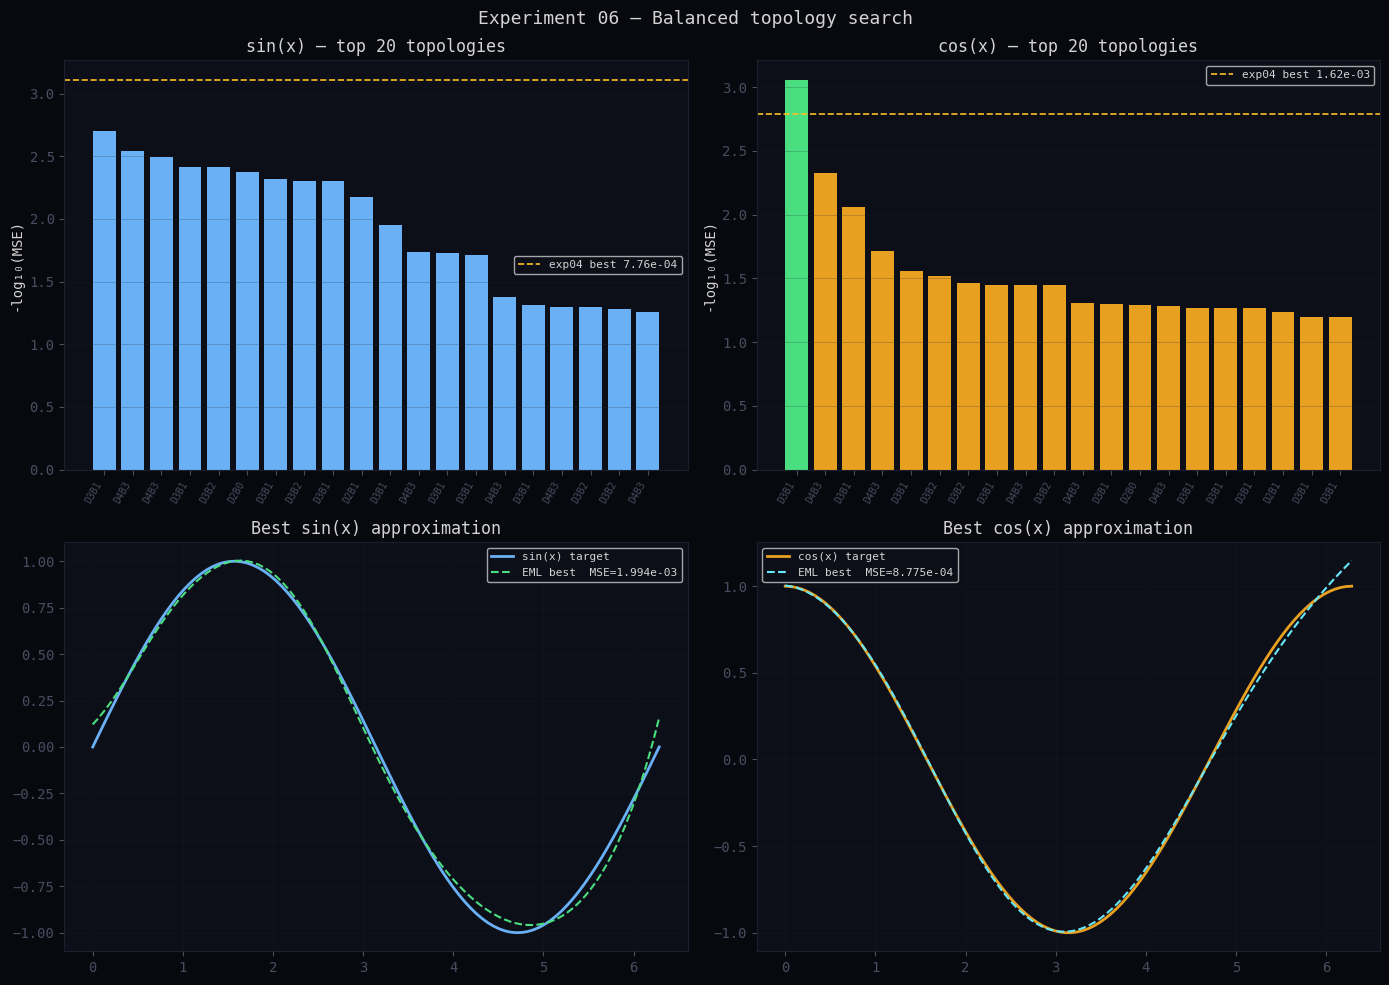

Saved → D:\monogate\python\notebooks\experiment_06_results.png


In [7]:
# ── Part C: plots ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experiment 06 — Balanced topology search', color='#d4d4d4', fontsize=13)

x_np  = x_grid.numpy()
sin_np = sin_target.numpy()
cos_np = cos_target.numpy()

# Panel A: sin(x) MSE bar chart (top 20)
ax = axes[0, 0]
top_sin = sin_results[:20]
colors_sin = [GREEN if r['loss'] < PREV_BEST_SIN else BLUE for r in top_sin]
bars = ax.bar(range(len(top_sin)), [-math.log10(r['loss']) for r in top_sin], color=colors_sin)
ax.axhline(-math.log10(PREV_BEST_SIN), color=GOLD, lw=1.2, ls='--', label=f'exp04 best {PREV_BEST_SIN:.2e}')
ax.set_xticks(range(len(top_sin)))
ax.set_xticklabels([f"D{r['depth']}B{r['balance']}" for r in top_sin], rotation=60, ha='right', fontsize=7)
ax.set_ylabel('-log₁₀(MSE)')
ax.set_title('sin(x) — top 20 topologies', color='#d4d4d4')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Panel B: cos(x) MSE bar chart (top 20)
ax = axes[0, 1]
top_cos = cos_results[:20]
colors_cos = [GREEN if r['loss'] < PREV_BEST_COS else ORANGE for r in top_cos]
bars = ax.bar(range(len(top_cos)), [-math.log10(r['loss']) for r in top_cos], color=colors_cos)
ax.axhline(-math.log10(PREV_BEST_COS), color=GOLD, lw=1.2, ls='--', label=f'exp04 best {PREV_BEST_COS:.2e}')
ax.set_xticks(range(len(top_cos)))
ax.set_xticklabels([f"D{r['depth']}B{r['balance']}" for r in top_cos], rotation=60, ha='right', fontsize=7)
ax.set_ylabel('-log₁₀(MSE)')
ax.set_title('cos(x) — top 20 topologies', color='#d4d4d4')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Panel C: best sin(x) fit
ax = axes[1, 0]
best_sin_model = sin_results[0]['_model']
with torch.no_grad():
    sin_pred = best_sin_model(x_in).numpy()
ax.plot(x_np, sin_np,  color=BLUE,  lw=2,   label='sin(x) target')
ax.plot(x_np, sin_pred, color=GREEN, lw=1.5, ls='--',
        label=f"EML best  MSE={sin_results[0]['loss']:.3e}")
ax.set_title('Best sin(x) approximation', color='#d4d4d4')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel D: best cos(x) fit
ax = axes[1, 1]
best_cos_model = cos_results[0]['_model']
with torch.no_grad():
    cos_pred = best_cos_model(x_in).numpy()
ax.plot(x_np, cos_np,  color=ORANGE, lw=2,   label='cos(x) target')
ax.plot(x_np, cos_pred, color=CYAN,  lw=1.5, ls='--',
        label=f"EML best  MSE={cos_results[0]['loss']:.3e}")
ax.set_title('Best cos(x) approximation', color='#d4d4d4')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
out_png = Path('experiment_06_results.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_png.resolve()}")


In [8]:
# ── Balance score vs MSE analysis ────────────────────────────────────────────

print("Balance score vs median MSE (sin):")
balance_groups = defaultdict(list)
for r in sin_results:
    balance_groups[r['balance']].append(r['loss'])

print(f"  {'Balance':<10} {'Count':<8} {'Median MSE':<14} {'Min MSE'}")
print('  ' + '─' * 48)
for b in sorted(balance_groups):
    vals = sorted(balance_groups[b])
    median = vals[len(vals)//2]
    print(f"  {b:<10} {len(vals):<8} {median:<14.4e} {vals[0]:.4e}")

print()
print("Balance score vs median MSE (cos):")
balance_groups_cos = defaultdict(list)
for r in cos_results:
    balance_groups_cos[r['balance']].append(r['loss'])

print(f"  {'Balance':<10} {'Count':<8} {'Median MSE':<14} {'Min MSE'}")
print('  ' + '─' * 48)
for b in sorted(balance_groups_cos):
    vals = sorted(balance_groups_cos[b])
    median = vals[len(vals)//2]
    print(f"  {b:<10} {len(vals):<8} {median:<14.4e} {vals[0]:.4e}")

print()
# Phantom statistics
n_phantom_sin = sum(1 for r in sin_results if r.get('phantom'))
n_phantom_cos = sum(1 for r in cos_results if r.get('phantom'))
print(f"Phantom attractors: sin={n_phantom_sin}/{len(sin_results)}, cos={n_phantom_cos}/{len(cos_results)}")
# Mixed refinement wins
mix_wins_sin = sum(1 for r in sin_results if r.get('pass_won') == 'mixed')
mix_wins_cos = sum(1 for r in cos_results if r.get('pass_won') == 'mixed')
print(f"Mixed-leaf improved top-5: sin={mix_wins_sin}, cos={mix_wins_cos}")


Balance score vs median MSE (sin):
  Balance    Count    Median MSE     Min MSE
  ────────────────────────────────────────────────
  0          1        4.2000e-03     4.2000e-03
  1          11       1.1211e-02     1.9941e-03
  2          5        5.0313e-02     3.8706e-03
  3          8        5.0220e-02     2.8604e-03

Balance score vs median MSE (cos):
  Balance    Count    Median MSE     Min MSE
  ────────────────────────────────────────────────
  0          1        5.1421e-02     5.1421e-02
  1          11       5.3863e-02     8.7748e-04
  2          5        3.5978e-02     3.0207e-02
  3          8        5.1788e-02     4.7434e-03

Phantom attractors: sin=0/25, cos=0/25
Mixed-leaf improved top-5: sin=0, cos=0


In [9]:
# ── Part D: Leaderboard export ───────────────────────────────────────────────

PREV_BESTS = {'sin': PREV_BEST_SIN, 'cos': PREV_BEST_COS}

leaderboard = {}
for target_name, results in [('sin', sin_results), ('cos', cos_results)]:
    top = []
    for r in results[:20]:
        top.append({
            'rank'      : len(top) + 1,
            'desc'      : r['desc'],
            'depth'     : r['depth'],
            'leaves'    : r['leaves'],
            'nodes'     : r['leaves'] - 1,
            'balance'   : r['balance'],
            'mse'       : r['loss'],
            'pass_won'  : r.get('pass_won', 'affine'),
            'phantom'   : r.get('phantom', False),
            'beats_prev': r['loss'] < PREV_BESTS[target_name],
            'formula'   : r['formula'],
        })
    leaderboard[target_name] = top

out_json = Path('experiment_06_results.json')
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(leaderboard, f, indent=2, ensure_ascii=False)
print(f"Saved → {out_json.resolve()}")

print()
print("═" * 72)
print("EXPERIMENT 06 FINAL LEADERBOARD")
print("═" * 72)

for target_name, results in [('sin', sin_results), ('cos', cos_results)]:
    prev = PREV_BESTS[target_name]
    best = results[0]
    beat_str = f"★ IMPROVEMENT +{(prev-best['loss'])/prev*100:.1f}%" if best['loss'] < prev else f"  (no improvement; prev {prev:.4e})"
    print(f"\n{'─'*72}")
    print(f"{target_name}(x)  best MSE: {best['loss']:.4e}  {beat_str}")
    print(f"  Depth={best['depth']}  Balance={best['balance']}  Pass={best.get('pass_won','affine')}")
    print(f"  Topology: {best['desc']}")
    print(f"  Formula:  {best['formula'][:80]}")
    print()
    print(f"  {'Rank':<6} {'D':<4} {'B':<4} {'MSE':<14} {'Pass':<8} {'Beat?':<8} {'Ph':<4}  Topology[:40]")
    print(f"  {'─'*75}")
    for r in leaderboard[target_name][:10]:
        beat = '★' if r['beats_prev'] else ' '
        ph   = 'PH' if r['phantom'] else '  '
        print(f"  {r['rank']:<6} {r['depth']:<4} {r['balance']:<4} {r['mse']:<14.4e} "
              f"{r['pass_won']:<8} {beat:<8} {ph:<4}  {r['desc'][:40]}")


Saved → D:\monogate\python\notebooks\experiment_06_results.json

════════════════════════════════════════════════════════════════════════
EXPERIMENT 06 FINAL LEADERBOARD
════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────
sin(x)  best MSE: 1.9941e-03    (no improvement; prev 7.7600e-04)
  Depth=3  Balance=1  Pass=affine
  Topology: eml(eml(1,eml(1,1)),eml(1,eml(1,1)))
  Formula:  eml(eml((0.2661*x+-0.822),eml((-0.1343*x+0.4235),(-0.08622*x+-0.9993))),eml((0.6

  Rank   D    B    MSE            Pass     Beat?    Ph    Topology[:40]
  ───────────────────────────────────────────────────────────────────────────
  1      3    1    1.9941e-03     affine                  eml(eml(1,eml(1,1)),eml(1,eml(1,1)))
  2      4    3    2.8604e-03     affine                  eml(1,eml(1,eml(eml(1,1),1)))
  3      4    3    3.1791e-03     affine                  eml(1,eml(1,eml(1,eml(1,1))))
  4      3    1    